In [6]:
import pandas as pd
import numpy as np
import warnings
from pathlib import Path
from src.config import PROCESSED_DATA_DIR, OUTPUT_DATA_DIR

# Suppress runtime warnings for divisions by zero in empty arrays
warnings.filterwarnings('ignore', category=RuntimeWarning)

# =========================================================
# 1. Metric Calculation Functions
# =========================================================
def calc_nse(obs, sim):
    valid_mask = ~(np.isnan(obs) | np.isnan(sim))
    obs, sim = obs[valid_mask], sim[valid_mask]
    if len(obs) == 0 or np.sum((obs - np.mean(obs))**2) == 0:
        return np.nan
    return 1 - (np.sum((sim - obs)**2) / np.sum((obs - np.mean(obs))**2))

def calc_kge(obs, sim):
    valid_mask = ~(np.isnan(obs) | np.isnan(sim))
    obs, sim = obs[valid_mask], sim[valid_mask]
    if len(obs) < 2 or np.std(obs) == 0:
        return np.nan
    r = np.corrcoef(obs, sim)[0, 1]
    alpha = np.std(sim) / np.std(obs)
    beta = np.mean(sim) / np.mean(obs)
    return 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

# =========================================================
# 2. Setup and Load Static / Index Data
# =========================================================
print("Loading observation data and setting up test indices...")

# Load attributes
df_attr = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0)
glac_stations = df_attr[df_attr['glacier_pct'] > 0.0].index

# Load ground truth streamflow (Units: m^3/s)
df_obs = pd.read_csv(PROCESSED_DATA_DIR / "combined_streamflow.csv", index_col='Date', parse_dates=True)

# Load the old test predictions JUST to extract the exact test dates and stations
df_test_template = pd.read_csv(OUTPUT_DATA_DIR / "test_set_predictions.csv", index_col=0, parse_dates=True)
test_dates = df_test_template.index
test_stations = df_test_template.columns

# Filter observations to test boundaries
df_obs_test = df_obs.loc[test_dates, test_stations].copy()

# Convert ground truth streamflow from m^3/s to mm/day
print("Converting ground truth units (m^3/s -> mm/day)...")
for stat in test_stations:
    area_km2 = df_attr.loc[stat, 'basin_area_km2']
    df_obs_test[stat] = df_obs_test[stat] * (86.4 / area_km2)

# Prep lists to hold the MEAN and MEDIAN metrics for each ensemble member
ens_mean_nse, ens_med_nse = [], []
ens_mean_kge, ens_med_kge = [], []
ens_mean_kge_aug, ens_med_kge_aug = [], []
ens_mean_kge_glac, ens_med_kge_glac = [], []
ens_mean_kge_aug_glac, ens_med_kge_aug_glac = [], []

ensemble_dir = OUTPUT_DATA_DIR / "phase_split"

# =========================================================
# 3. Iterate Through Ensemble Members
# =========================================================
print("Processing 10 ensemble members...")

for i in range(10):
    file_path = ensemble_dir / f"phase-split_preds_member_{i}.csv"
    
    # Load member predictions and isolate test data (Units: mm/day)
    df_pred = pd.read_csv(file_path, index_col=0, parse_dates=True)
    df_pred_test = df_pred.loc[test_dates, test_stations]
    
    # Track metrics for THIS specific ensemble member across all stations
    mem_nse_all, mem_kge_all, mem_kge_aug = [], [], []
    mem_kge_glac, mem_kge_aug_glac = [], []
    
    for stat in test_stations:
        obs = df_obs_test[stat].values
        sim = df_pred_test[stat].values
        
        # August specifically
        aug_mask = test_dates.month == 8
        obs_aug = obs[aug_mask]
        sim_aug = sim[aug_mask]
        
        # Calculate metrics
        nse = calc_nse(obs, sim)
        kge = calc_kge(obs, sim)
        kge_aug = calc_kge(obs_aug, sim_aug)
        
        mem_nse_all.append(nse)
        mem_kge_all.append(kge)
        mem_kge_aug.append(kge_aug)
        
        if stat in glac_stations:
            mem_kge_glac.append(kge)
            mem_kge_aug_glac.append(kge_aug)
            
    # Calculate both MEAN and MEDIAN station performance for THIS member
    ens_mean_nse.append(np.nanmean(mem_nse_all))
    ens_med_nse.append(np.nanmedian(mem_nse_all))
    
    ens_mean_kge.append(np.nanmean(mem_kge_all))
    ens_med_kge.append(np.nanmedian(mem_kge_all))
    
    ens_mean_kge_aug.append(np.nanmean(mem_kge_aug))
    ens_med_kge_aug.append(np.nanmedian(mem_kge_aug))
    
    ens_mean_kge_glac.append(np.nanmean(mem_kge_glac))
    ens_med_kge_glac.append(np.nanmedian(mem_kge_glac))
    
    ens_mean_kge_aug_glac.append(np.nanmean(mem_kge_aug_glac))
    ens_med_kge_aug_glac.append(np.nanmedian(mem_kge_aug_glac))

# =========================================================
# 4. Report Final Ensemble Statistics
# =========================================================
print("\n" + "="*60)
print("ENSEMBLE TEST PERFORMANCE (10 Members)")
print("="*60)

def print_stat(name, mean_list, med_list):
    print(f"{name}:")
    print(f"  Station Means   : {np.mean(mean_list):5.3f} ± {np.std(mean_list):.3f}")
    print(f"  Station Medians : {np.mean(med_list):5.3f} ± {np.std(med_list):.3f}")
    print("-" * 60)

print_stat("Overall NSE (All Stations)", ens_mean_nse, ens_med_nse)
print_stat("Overall KGE (All Stations)", ens_mean_kge, ens_med_kge)
print_stat("August KGE (All Stations)", ens_mean_kge_aug, ens_med_kge_aug)
print_stat("KGE on Glaciated Stations", ens_mean_kge_glac, ens_med_kge_glac)
print_stat("August KGE on Glaciated Stations", ens_mean_kge_aug_glac, ens_med_kge_aug_glac)

Loading observation data and setting up test indices...
Converting ground truth units (m^3/s -> mm/day)...
Processing 10 ensemble members...

ENSEMBLE TEST PERFORMANCE (10 Members)
Overall NSE (All Stations):
  Station Means   : 0.586 ± 0.054
  Station Medians : 0.707 ± 0.015
------------------------------------------------------------
Overall KGE (All Stations):
  Station Means   : 0.611 ± 0.022
  Station Medians : 0.692 ± 0.032
------------------------------------------------------------
August KGE (All Stations):
  Station Means   : -28.780 ± 14.262
  Station Medians : 0.468 ± 0.022
------------------------------------------------------------
KGE on Glaciated Stations:
  Station Means   : 0.833 ± 0.016
  Station Medians : 0.873 ± 0.019
------------------------------------------------------------
August KGE on Glaciated Stations:
  Station Means   : 0.639 ± 0.033
  Station Medians : 0.687 ± 0.020
------------------------------------------------------------


Loading data and imputing...
Calculating median KGE across 10 ensemble members...
Computing hydrographs and clustering...
Generating Voronoi spatial grid...
Rendering final plot...


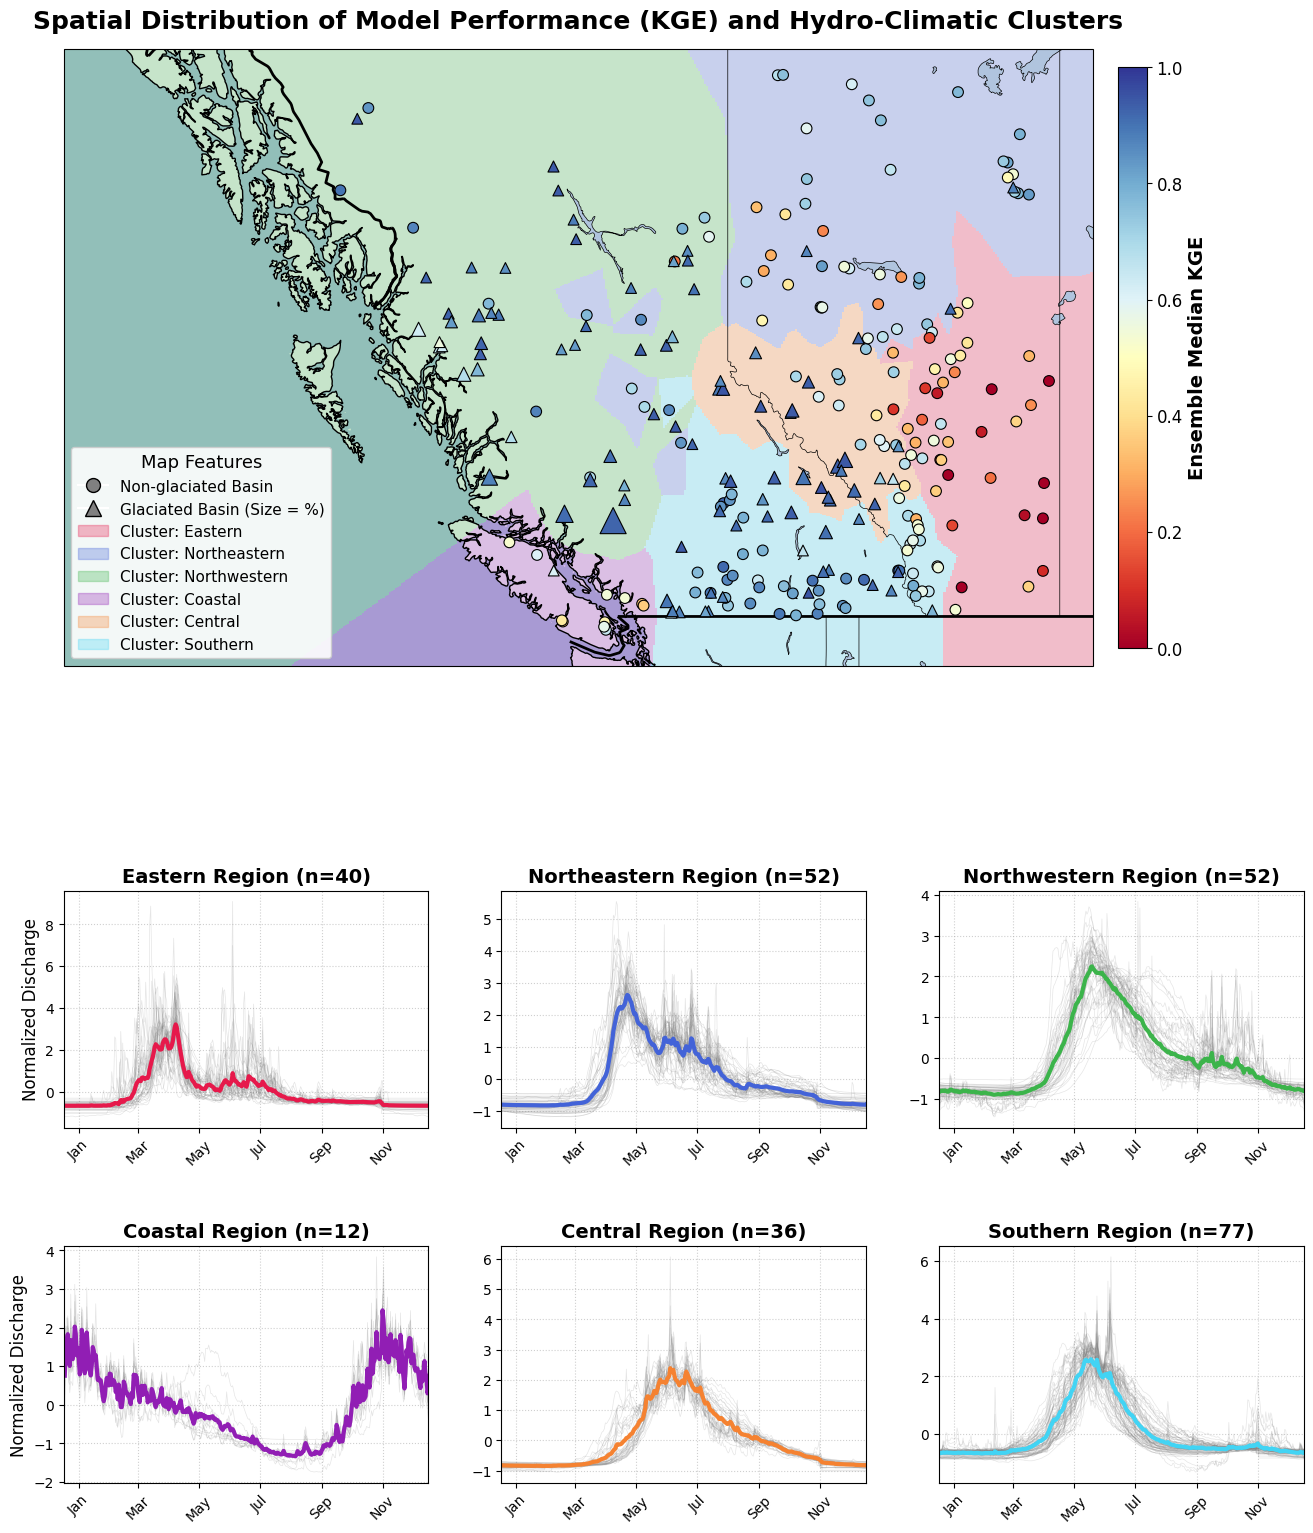

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.neighbors import KNeighborsClassifier
from matplotlib.colors import ListedColormap, Normalize
import matplotlib.cm as cm
import warnings
from src.config import PROCESSED_DATA_DIR, RAW_DATA_DIR, OUTPUT_DATA_DIR

warnings.filterwarnings('ignore')

# =========================================================
# 1. Metric Calculation Function
# =========================================================
def calc_kge(obs, sim):
    valid_mask = ~(np.isnan(obs) | np.isnan(sim))
    obs, sim = obs[valid_mask], sim[valid_mask]
    if len(obs) < 2 or np.std(obs) == 0:
        return np.nan
    r = np.corrcoef(obs, sim)[0, 1]
    alpha = np.std(sim) / np.std(obs)
    beta = np.mean(sim) / np.mean(obs)
    return 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

# =========================================================
# 2. Load Data & Impute
# =========================================================
print("Loading data and imputing...")
df_obs = pd.read_csv(PROCESSED_DATA_DIR / "combined_streamflow.csv", index_col='Date', parse_dates=True)
df_meta = pd.read_csv(RAW_DATA_DIR / "station_metadata.csv", index_col=0) 
df_attr = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0) 

# Convert streamflow to mm/day for KGE calculation
for stat in df_obs.columns:
    if stat in df_attr.index:
        area_km2 = df_attr.loc[stat, 'basin_area_km2']
        df_obs[stat] = df_obs[stat] * (86.4 / area_km2)

# Imputation for Hydrographs
df_obs_imputed = df_obs.interpolate(method='linear', limit=7)
df_obs_imputed = df_obs_imputed.fillna(df_obs_imputed.groupby(df_obs_imputed.index.dayofyear).transform('mean'))
df_obs_imputed = df_obs_imputed.fillna(df_obs_imputed.groupby(df_obs_imputed.index.year).transform('min'))
df_obs_imputed = df_obs_imputed.fillna(df_obs_imputed.min())

# =========================================================
# 3. Calculate KGE across Ensemble
# =========================================================
print("Calculating median KGE across 10 ensemble members...")
ensemble_dir = OUTPUT_DATA_DIR / "phase_split"
all_stations = df_obs.columns
station_kge_lists = {stat: [] for stat in all_stations}

# Read all members and calculate KGE for the available timeseries
for i in range(10):
    df_pred = pd.read_csv(ensemble_dir / f"phase-split_preds_member_{i}.csv", index_col=0, parse_dates=True)
    # Align dates
    common_dates = df_obs.index.intersection(df_pred.index)
    
    for stat in all_stations:
        if stat in df_pred.columns:
            obs_vals = df_obs.loc[common_dates, stat].values
            sim_vals = df_pred.loc[common_dates, stat].values
            station_kge_lists[stat].append(calc_kge(obs_vals, sim_vals))

# Get the median KGE per station, clipped between 0 and 1
station_median_kge = {}
for stat, kge_list in station_kge_lists.items():
    med_kge = np.nanmedian(kge_list)
    station_median_kge[stat] = np.clip(med_kge, 0, 1)

df_kge = pd.DataFrame.from_dict(station_median_kge, orient='index', columns=['KGE'])

# =========================================================
# 4. Clustering
# =========================================================
print("Computing hydrographs and clustering...")
avg_hydrograph = df_obs_imputed.groupby(df_obs_imputed.index.dayofyear).mean()
avg_hydrograph_norm = (avg_hydrograph - avg_hydrograph.mean()) / avg_hydrograph.std()

X_hydro = avg_hydrograph_norm.T
X_merged = X_hydro.join(df_meta[['Latitude', 'Longitude']], how='inner')

hydro_features = X_merged.drop(columns=['Latitude', 'Longitude']).values
lat_norm = (X_merged['Latitude'] - X_merged['Latitude'].mean()) / X_merged['Latitude'].std()
lon_norm = (X_merged['Longitude'] - X_merged['Longitude'].mean()) / X_merged['Longitude'].std()

lat_features = np.tile(lat_norm.values, (182, 1)).T
lon_features = np.tile(lon_norm.values, (182, 1)).T

X_cluster_input = np.hstack((hydro_features, lat_features, lon_features))
Z = linkage(X_cluster_input, method='ward')

cluster_labels = fcluster(Z, t=6, criterion='maxclust') - 1

df_plot = pd.DataFrame({'Cluster': cluster_labels}, index=X_merged.index)
df_plot = df_plot.join(df_meta[['Latitude', 'Longitude']], how='inner')
df_plot = df_plot.join(df_attr[['glacier_pct']], how='left')
df_plot = df_plot.join(df_kge, how='inner')
df_plot['glacier_pct'] = df_plot['glacier_pct'].fillna(0)

cluster_names = {0: "Eastern", 1: "Northeastern", 2: "Northwestern", 3: "Coastal", 4: "Central", 5: "Southern"}
# Colors for the 6 clusters (Voronoi background)
cluster_colors = ['#e6194B', '#4363d8', '#3cb44b', '#911eb4', '#f58231', '#42d4f4']
cmap_clusters = ListedColormap(cluster_colors)

# =========================================================
# 5. Generate Voronoi Grid (KNN Approach)
# =========================================================
print("Generating Voronoi spatial grid...")
# Train KNN on station coordinates and cluster labels
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(df_plot[['Longitude', 'Latitude']], df_plot['Cluster'])

# Create a dense grid over the map area
xx, yy = np.meshgrid(np.linspace(-140, -109, 500), np.linspace(48, 59, 500))
# Predict the cluster for every point in the grid
Z_grid = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z_grid = Z_grid.reshape(xx.shape)

# =========================================================
# 6. Plotting - Master Layout
# =========================================================
print("Rendering final plot...")
fig = plt.figure(figsize=(16, 20))
# Create a grid: Top half for the map, bottom half for the 6 hydrographs
gs = fig.add_gridspec(4, 3, height_ratios=[1.5, 1.5, 1, 1], hspace=0.4)

# --- PANEL A: The Map ---
ax_map = fig.add_subplot(gs[0:2, :], projection=ccrs.Mercator())
ax_map.set_extent([-140, -109, 48, 59], crs=ccrs.PlateCarree())

res = '10m' 
ax_map.add_feature(cfeature.LAND.with_scale(res), facecolor='whitesmoke', zorder=0)
ax_map.add_feature(cfeature.OCEAN.with_scale(res), facecolor='lightsteelblue', zorder=0)
ax_map.add_feature(cfeature.COASTLINE.with_scale(res), edgecolor='black', zorder=2)
ax_map.add_feature(cfeature.LAKES.with_scale(res), facecolor='lightsteelblue', edgecolor='black', linewidth=0.5, zorder=2)

provinces = cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lines', scale=res, facecolor='none')
ax_map.add_feature(provinces, edgecolor='black', linewidth=0.5, zorder=3)
ax_map.add_feature(cfeature.BORDERS.with_scale(res), linestyle='-', edgecolor='black', linewidth=2.0, zorder=3)

# Plot the Voronoi Background (Alpha is low so it acts as shading)
ax_map.pcolormesh(xx, yy, Z_grid, cmap=cmap_clusters, alpha=0.25, transform=ccrs.PlateCarree(), zorder=1)

# Plot the KGE Heatmap Points
# Using 'RdYlBu' where Red = 0 (Bad), Blue = 1 (Good)
sc_non_glac = ax_map.scatter(
    df_plot[df_plot['glacier_pct'] == 0]['Longitude'], 
    df_plot[df_plot['glacier_pct'] == 0]['Latitude'],
    c=df_plot[df_plot['glacier_pct'] == 0]['KGE'],
    cmap='RdYlBu', vmin=0, vmax=1,
    s=60, marker='o', edgecolors='k', linewidths=0.8, transform=ccrs.PlateCarree(), zorder=5
)

sc_glac = ax_map.scatter(
    df_plot[df_plot['glacier_pct'] > 0]['Longitude'], 
    df_plot[df_plot['glacier_pct'] > 0]['Latitude'],
    c=df_plot[df_plot['glacier_pct'] > 0]['KGE'],
    cmap='RdYlBu', vmin=0, vmax=1,
    s=(df_plot[df_plot['glacier_pct'] > 0]['glacier_pct'] * 5) + 60, 
    marker='^', edgecolors='k', linewidths=0.8, transform=ccrs.PlateCarree(), zorder=6
)

# Add Colorbar for KGE
cbar = plt.colorbar(sc_non_glac, ax=ax_map, orientation='vertical', pad=0.02, shrink=0.7)
cbar.set_label('Ensemble Median KGE', fontsize=14, fontweight='bold')
cbar.ax.tick_params(labelsize=12)

# Build Custom Legend
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, markeredgecolor='k', label='Non-glaciated Basin'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', markersize=12, markeredgecolor='k', label='Glaciated Basin (Size = %)')
]
# Add cluster colors to legend
for i in range(6):
    legend_elements.append(mpatches.Patch(color=cluster_colors[i], alpha=0.3, label=f'Cluster: {cluster_names[i]}'))

ax_map.legend(handles=legend_elements, loc='lower left', title="Map Features", fontsize=11, title_fontsize=13, framealpha=0.9)
ax_map.set_title('Spatial Distribution of Model Performance (KGE) and Hydro-Climatic Clusters', fontsize=18, fontweight='bold', pad=15)

# --- PANEL B: The Hydrographs ---
month_ticks = [15, 74, 135, 196, 258, 319]
month_labels = ['Jan', 'Mar', 'May', 'Jul', 'Sep', 'Nov']

for cluster_id in range(6):
    # Calculate grid position for hydrographs (Rows 2 and 3 of the gridspec)
    row = 2 + (cluster_id // 3)
    col = cluster_id % 3
    ax = fig.add_subplot(gs[row, col])
    
    station_names = df_plot[df_plot['Cluster'] == cluster_id].index
    cluster_hydro_data = avg_hydrograph_norm[station_names]
    
    # Plot individual faint lines
    ax.plot(cluster_hydro_data.index, cluster_hydro_data.values, color='gray', alpha=0.2, linewidth=0.5)
    
    # Plot thick mean line
    cluster_mean = cluster_hydro_data.mean(axis=1)
    ax.plot(cluster_mean.index, cluster_mean.values, color=cluster_colors[cluster_id], linewidth=3)
    
    ax.set_title(f"{cluster_names[cluster_id]} Region (n={len(station_names)})", fontsize=14, fontweight='bold')
    ax.set_xticks(month_ticks)
    ax.set_xticklabels(month_labels, rotation=45)
    ax.set_xlim(0, 365)
    ax.grid(True, linestyle=':', alpha=0.6)
    
    if col == 0:
        ax.set_ylabel('Normalized Discharge', fontsize=12)

plt.show()

Calculating ensemble mean predictions...


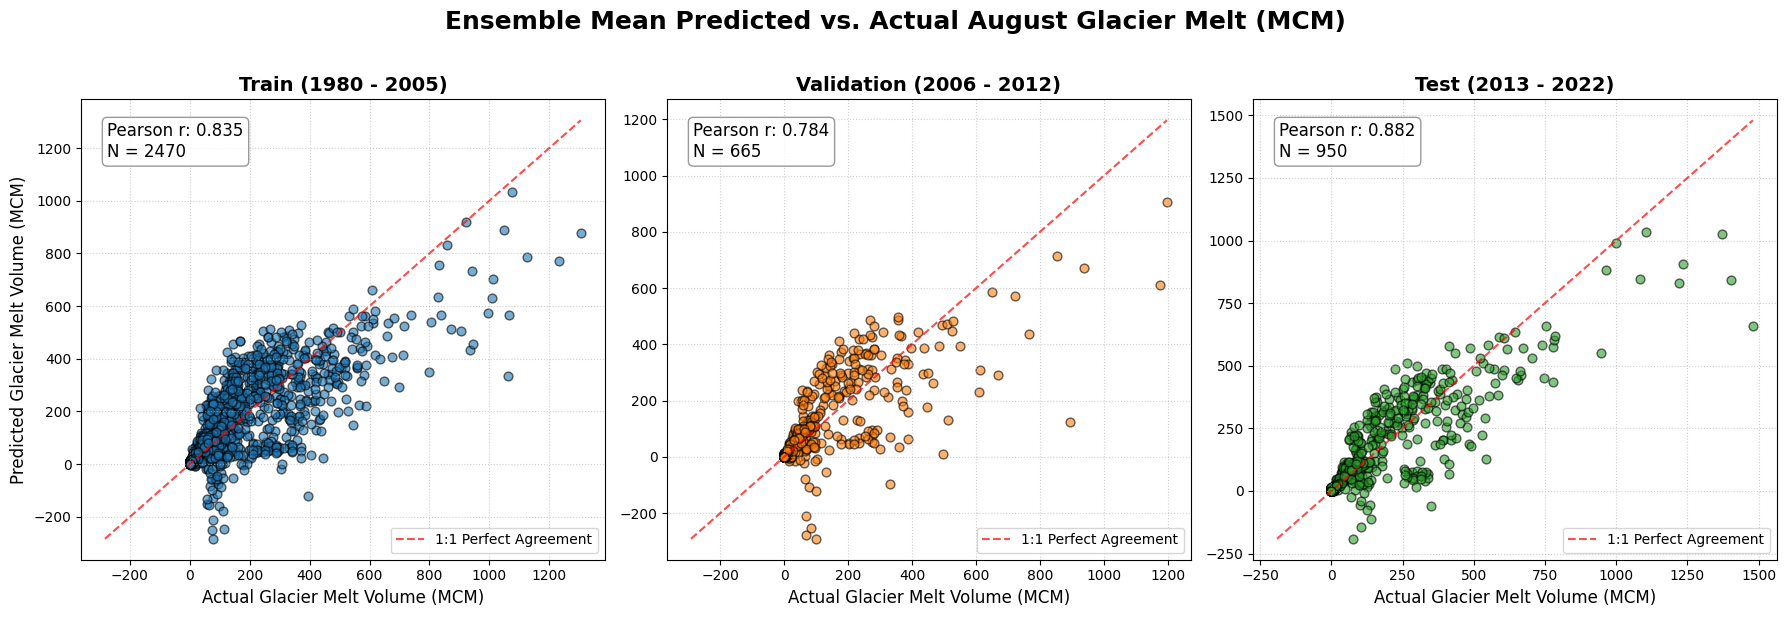

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from src.config import PROCESSED_DATA_DIR, OUTPUT_DATA_DIR

# =========================================================
# 1. Setup Data Paths & Lists
# =========================================================
ensemble_dir = OUTPUT_DATA_DIR / "phase_split"
num_members = 10

# Load attributes to identify glaciated stations
df_attr = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0)
glaciated_stations = df_attr[df_attr['glacier_pct'] > 0].index

# Load Mass Balance (True Melt) - Already in MCM
df_mb = -pd.read_csv(PROCESSED_DATA_DIR / "glacier_volume_change.csv", index_col=0, parse_dates=True)

# Find common stations across attributes and mass balance
common_stations = glaciated_stations.intersection(df_mb.columns)
df_mb = df_mb[common_stations]
basin_areas = df_attr.loc[common_stations, 'basin_area_km2']

# =========================================================
# 2. Calculate Ensemble Mean Predictions
# =========================================================
print("Calculating ensemble mean predictions...")
list_diff_mcm = []

for i in range(num_members):
    # Load the baseline and counterfactual for the specific ensemble member
    df_pred = pd.read_csv(ensemble_dir / f"phase-split_preds_member_{i}.csv", index_col=0, parse_dates=True)[common_stations]
    df_pred_no_glac = pd.read_csv(ensemble_dir / f"phase-split_preds_noglacier_member_{i}.csv", index_col=0, parse_dates=True)[common_stations]
    
    # Calculate daily difference (mm/day)
    df_diff_mm = df_pred - df_pred_no_glac
    
    # Isolate August and sum to get monthly total (mm/month)
    df_diff_aug_mm = df_diff_mm[df_diff_mm.index.month == 8].groupby(df_diff_mm[df_diff_mm.index.month == 8].index.year).sum()
    
    # Convert depth (mm) to volume (MCM)
    df_diff_aug_mcm = df_diff_aug_mm * basin_areas * 0.001
    list_diff_mcm.append(df_diff_aug_mcm)

# Average all 10 DataFrames together to get the Ensemble Mean Prediction
df_pred_mcm_mean = sum(list_diff_mcm) / num_members

# Calculate Actual Mass Balance Yearly Sums
df_mb_aug_yearly = df_mb[df_mb.index.month == 8].groupby(df_mb[df_mb.index.month == 8].index.year).sum()

# Align years
common_years = df_mb_aug_yearly.index.intersection(df_pred_mcm_mean.index)
df_actual_mcm = df_mb_aug_yearly.loc[common_years]
df_pred_mcm = df_pred_mcm_mean.loc[common_years]

# =========================================================
# 3. Define Periods & Prep Plotting Function
# =========================================================
periods = {
    'Train (1980 - 2005)': (1980, 2005),
    'Validation (2006 - 2012)': (2006, 2012),
    'Test (2013 - 2022)': (2013, 2022)
}

def get_clean_flat_data(df_actual, df_pred, start_yr, end_yr):
    # Slice dataframe to specific years
    mask = (df_actual.index >= start_yr) & (df_actual.index <= end_yr)
    act_slice = df_actual[mask].values.flatten()
    pred_slice = df_pred[mask].values.flatten()
    
    valid_mask = ~(np.isnan(act_slice) | np.isnan(pred_slice))
    x_clean = act_slice[valid_mask]
    y_clean = pred_slice[valid_mask]
    
    corr, _ = stats.pearsonr(x_clean, y_clean)
    return x_clean, y_clean, corr

# =========================================================
# 4. Plotting
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
colors = ['tab:blue', 'tab:orange', 'tab:green']

for i, (period_name, (start_yr, end_yr)) in enumerate(periods.items()):
    ax = axes[i]
    x, y, corr = get_clean_flat_data(df_actual_mcm, df_pred_mcm, start_yr, end_yr)
    
    ax.scatter(x, y, color=colors[i], alpha=0.6, edgecolor='k', s=40)
    
    ax.set_title(f'{period_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Actual Glacier Melt Volume (MCM)', fontsize=12)
    
    if i == 0:
        ax.set_ylabel('Predicted Glacier Melt Volume (MCM)', fontsize=12)
        
    # Correlation Text
    ax.text(0.05, 0.95, f'Pearson r: {corr:.3f}\nN = {len(x)}', transform=ax.transAxes, 
            fontsize=12, verticalalignment='top', bbox=props)
            
    # 1:1 Line
    max_val = max(x.max(), y.max())
    min_val = min(min(x), min(y), 0)
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.7, label='1:1 Perfect Agreement')
    
    ax.legend(loc='lower right')
    ax.grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Ensemble Mean Predicted vs. Actual August Glacier Melt (MCM)', fontsize=18, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

Calculating ensemble statistics...


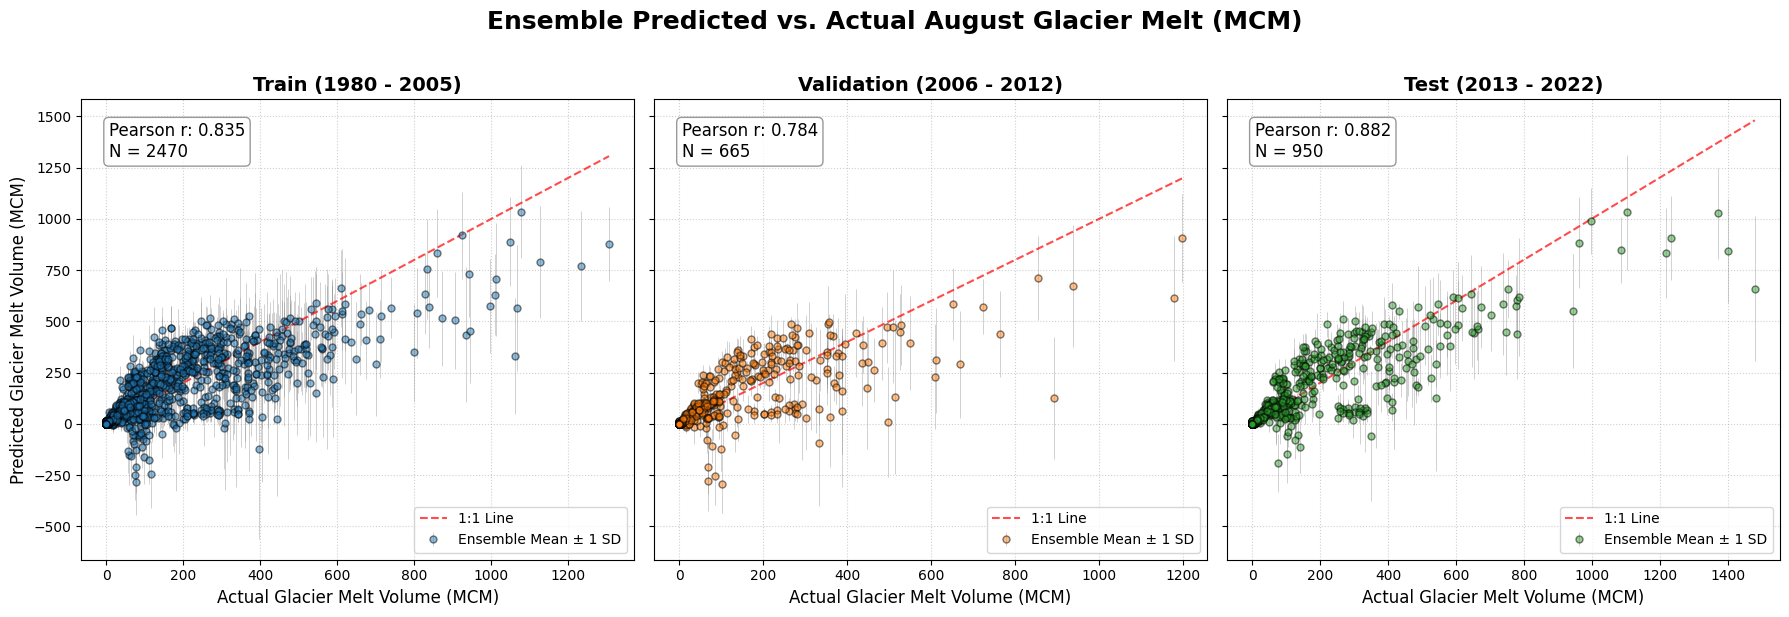

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from src.config import PROCESSED_DATA_DIR, OUTPUT_DATA_DIR

# =========================================================
# 1. Setup Data Paths & Lists
# =========================================================
ensemble_dir = OUTPUT_DATA_DIR / "phase_split"
num_members = 10

df_attr = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0)
glaciated_stations = df_attr[df_attr['glacier_pct'] > 0].index

df_mb = -pd.read_csv(PROCESSED_DATA_DIR / "glacier_volume_change.csv", index_col=0, parse_dates=True)
common_stations = glaciated_stations.intersection(df_mb.columns)
df_mb = df_mb[common_stations]
basin_areas = df_attr.loc[common_stations, 'basin_area_km2']

# =========================================================
# 2. Calculate Ensemble Mean & Std
# =========================================================
print("Calculating ensemble statistics...")
list_diff_mcm = []

for i in range(num_members):
    df_pred = pd.read_csv(ensemble_dir / f"phase-split_preds_member_{i}.csv", index_col=0, parse_dates=True)[common_stations]
    df_pred_no_glac = pd.read_csv(ensemble_dir / f"phase-split_preds_noglacier_member_{i}.csv", index_col=0, parse_dates=True)[common_stations]
    
    df_diff_mm = df_pred - df_pred_no_glac
    df_diff_aug_mm = df_diff_mm[df_diff_mm.index.month == 8].groupby(df_diff_mm[df_diff_mm.index.month == 8].index.year).sum()
    df_diff_aug_mcm = df_diff_aug_mm * basin_areas * 0.001
    list_diff_mcm.append(df_diff_aug_mcm)

# Stack to 3D array (Member, Year, Station) to compute stats across axis 0
stacked_diffs = np.stack([df.values for df in list_diff_mcm], axis=0)
mean_vals = np.mean(stacked_diffs, axis=0)
std_vals = np.std(stacked_diffs, axis=0)

# Reconstruct into DataFrames
df_pred_mcm_mean = pd.DataFrame(mean_vals, index=list_diff_mcm[0].index, columns=list_diff_mcm[0].columns)
df_pred_mcm_std = pd.DataFrame(std_vals, index=list_diff_mcm[0].index, columns=list_diff_mcm[0].columns)

df_mb_aug_yearly = df_mb[df_mb.index.month == 8].groupby(df_mb[df_mb.index.month == 8].index.year).sum()
common_years = df_mb_aug_yearly.index.intersection(df_pred_mcm_mean.index)

df_actual_mcm = df_mb_aug_yearly.loc[common_years]
df_pred_mcm = df_pred_mcm_mean.loc[common_years]
df_std_mcm = df_pred_mcm_std.loc[common_years]

# =========================================================
# 3. Updated Prep Plotting Function
# =========================================================
def get_clean_flat_data(df_actual, df_pred, df_std, start_yr, end_yr):
    mask = (df_actual.index >= start_yr) & (df_actual.index <= end_yr)
    
    act_slice = df_actual[mask].values.flatten()
    pred_slice = df_pred[mask].values.flatten()
    std_slice = df_std[mask].values.flatten()
    
    valid_mask = ~(np.isnan(act_slice) | np.isnan(pred_slice))
    x_clean = act_slice[valid_mask]
    y_clean = pred_slice[valid_mask]
    yerr_clean = std_slice[valid_mask]
    
    corr, _ = stats.pearsonr(x_clean, y_clean)
    return x_clean, y_clean, yerr_clean, corr

# =========================================================
# 4. Plotting with Error Bars
# =========================================================
periods = {
    'Train (1980 - 2005)': (1980, 2005),
    'Validation (2006 - 2012)': (2006, 2012),
    'Test (2013 - 2022)': (2013, 2022)
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
colors = ['tab:blue', 'tab:orange', 'tab:green']

for i, (period_name, (start_yr, end_yr)) in enumerate(periods.items()):
    ax = axes[i]
    x, y, yerr, corr = get_clean_flat_data(df_actual_mcm, df_pred_mcm, df_std_mcm, start_yr, end_yr)
    
    # Using errorbar instead of scatter
    ax.errorbar(x, y, yerr=yerr, fmt='o', color=colors[i], 
                ecolor='gray', elinewidth=0.5, capsize=0, 
                alpha=0.5, markeredgecolor='k', ms=5, label='Ensemble Mean ± 1 SD')
    
    ax.set_title(f'{period_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Actual Glacier Melt Volume (MCM)', fontsize=12)
    if i == 0:
        ax.set_ylabel('Predicted Glacier Melt Volume (MCM)', fontsize=12)
        
    ax.text(0.05, 0.95, f'Pearson r: {corr:.3f}\nN = {len(x)}', transform=ax.transAxes, 
            fontsize=12, verticalalignment='top', bbox=props)
            
    # 1:1 Line
    limit = max(x.max(), y.max()) if len(x) > 0 else 10
    ax.plot([0, limit], [0, limit], 'r--', alpha=0.7, label='1:1 Line')
    
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='lower right', fontsize=10)

plt.suptitle('Ensemble Predicted vs. Actual August Glacier Melt (MCM)', fontsize=18, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

Loading data and calculating ensemble means...
Calculating KGE and Melt Residuals per Station-Year...


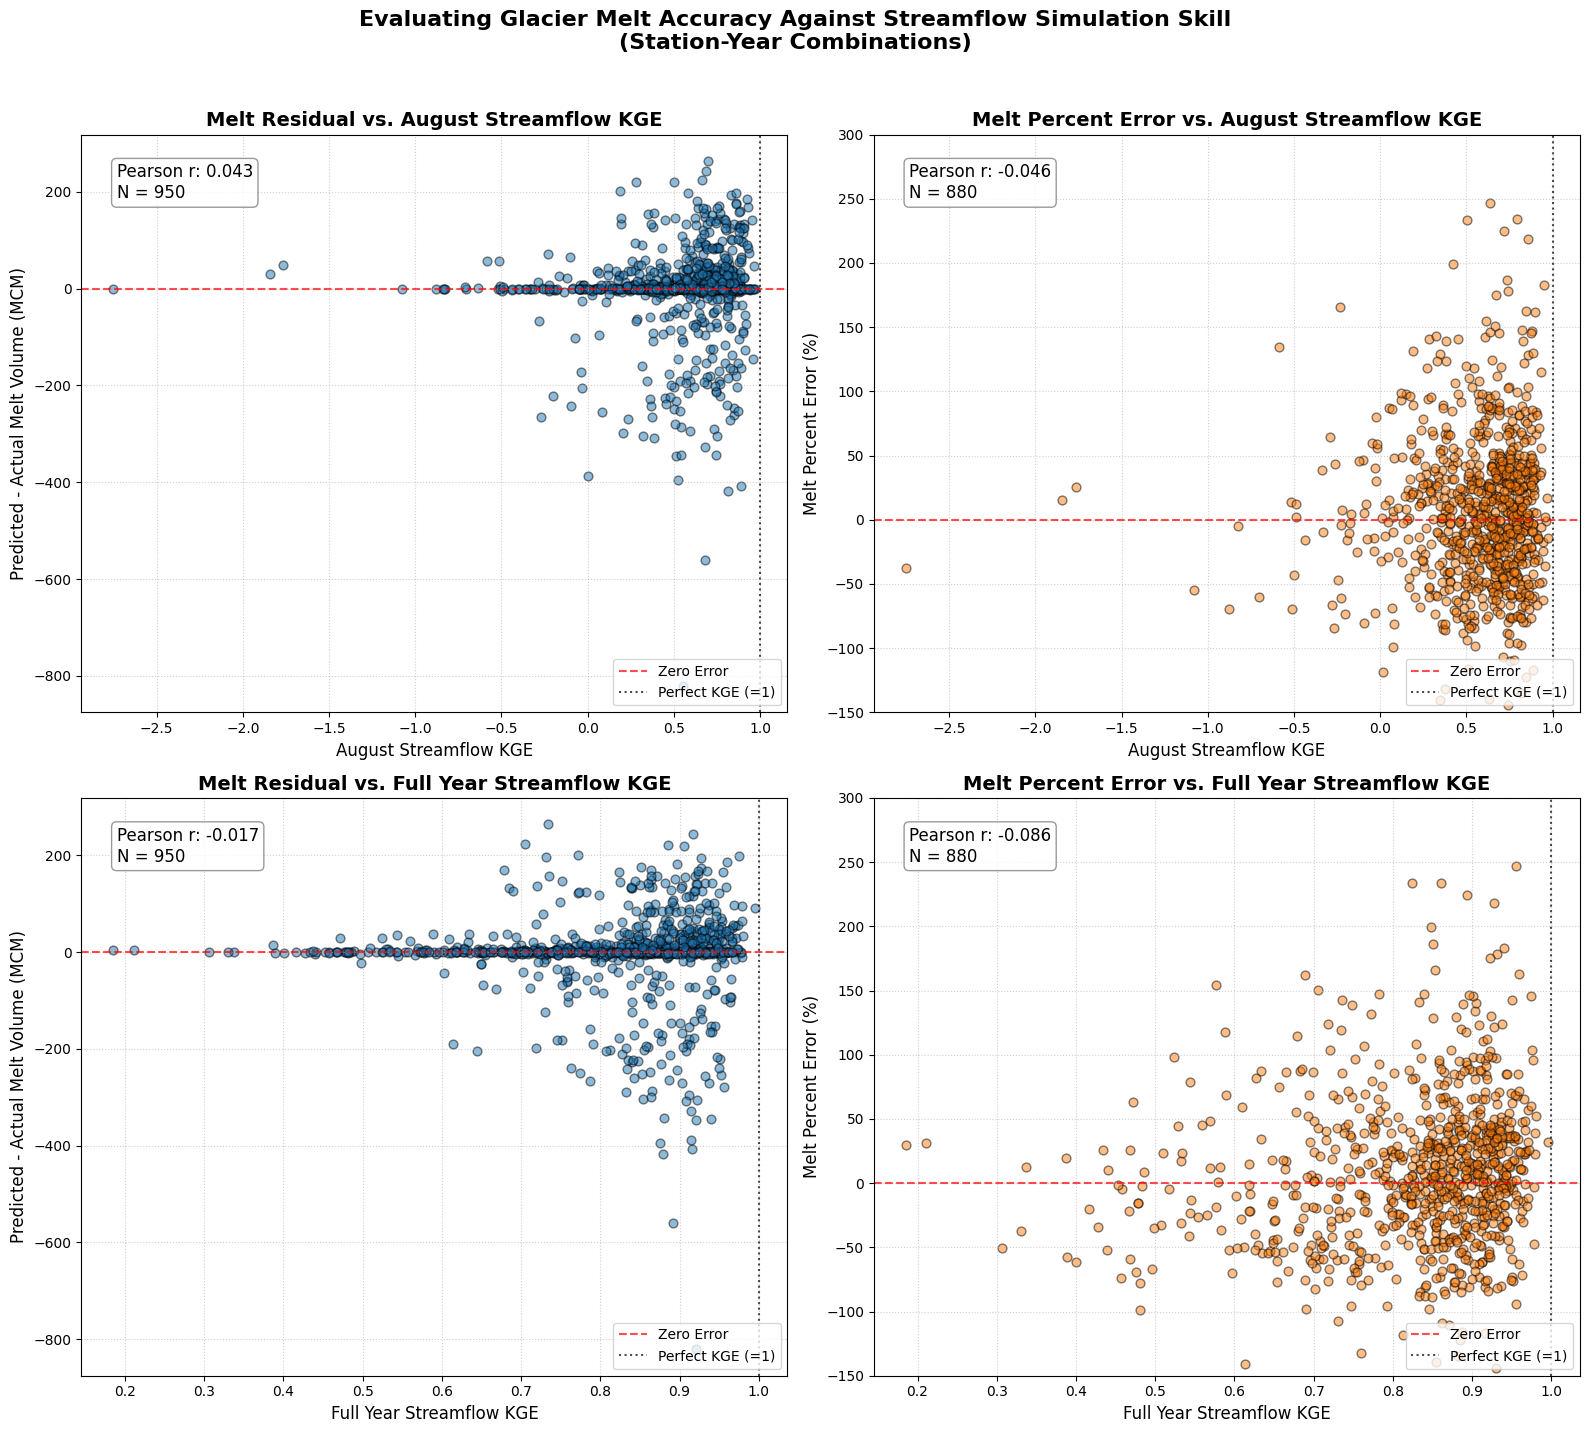

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
from src.config import PROCESSED_DATA_DIR, OUTPUT_DATA_DIR

warnings.filterwarnings('ignore', category=RuntimeWarning)

# =========================================================
# 1. KGE Calculation Function
# =========================================================
def calc_kge(obs, sim):
    valid_mask = ~(np.isnan(obs) | np.isnan(sim))
    obs, sim = obs[valid_mask], sim[valid_mask]
    if len(obs) < 2 or np.std(obs) == 0:
        return np.nan
    r = np.corrcoef(obs, sim)[0, 1]
    alpha = np.std(sim) / np.std(obs)
    beta = np.mean(sim) / np.mean(obs)
    return 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

# =========================================================
# 2. Setup & Load Data
# =========================================================
print("Loading data and calculating ensemble means...")

df_attr = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0)
df_obs = pd.read_csv(PROCESSED_DATA_DIR / "combined_streamflow.csv", index_col='Date', parse_dates=True)
df_mb = -pd.read_csv(PROCESSED_DATA_DIR / "glacier_volume_change.csv", index_col=0, parse_dates=True) # Native MCM

# Get template for test dates/stations
df_test_template = pd.read_csv(OUTPUT_DATA_DIR / "test_set_predictions.csv", index_col=0, parse_dates=True)
test_dates = df_test_template.index

glaciated_stations = df_attr[df_attr['glacier_pct'] > 0].index
common_stations = glaciated_stations.intersection(df_test_template.columns).intersection(df_mb.columns).intersection(df_obs.columns)

df_obs_test = df_obs.loc[test_dates, common_stations].copy()

# --- THE FIX ---
# Since df_mb is monthly, we CANNOT slice it with the daily test_dates index.
# We just isolate the common stations and leave the monthly index intact.
df_mb_test = df_mb[common_stations].copy()

# Convert Obs to mm/day
basin_areas = df_attr.loc[common_stations, 'basin_area_km2']
for stat in common_stations:
    df_obs_test[stat] = df_obs_test[stat] * (86.4 / basin_areas[stat])

# --- Calculate Ensemble Means ---
ensemble_dir = OUTPUT_DATA_DIR / "phase_split"
list_pred, list_noglac = [], []

for i in range(10):
    pred = pd.read_csv(ensemble_dir / f"phase-split_preds_member_{i}.csv", index_col=0, parse_dates=True)
    noglac = pd.read_csv(ensemble_dir / f"phase-split_preds_noglacier_member_{i}.csv", index_col=0, parse_dates=True)
    list_pred.append(pred.loc[test_dates, common_stations])
    list_noglac.append(noglac.loc[test_dates, common_stations])

df_pred_mean = sum(list_pred) / 10
df_noglac_mean = sum(list_noglac) / 10

# =========================================================
# 3. Calculate Station-Yearly Metrics
# =========================================================
print("Calculating KGE and Melt Residuals per Station-Year...")
test_years = np.unique(test_dates.year)
records = []

for y in test_years:
    for s in common_stations:
        # Timeseries slices
        obs_y = df_obs_test.loc[str(y), s].values
        pred_y = df_pred_mean.loc[str(y), s].values
        
        obs_aug = df_obs_test.loc[f"{y}-08", s].values
        pred_aug = df_pred_mean.loc[f"{y}-08", s].values
        
        # Calculate KGEs
        kge_year = calc_kge(obs_y, pred_y)
        kge_aug = calc_kge(obs_aug, pred_aug)
        
        # Calculate Melt Volumes (MCM)
        pred_melt_mm_sum = df_pred_mean.loc[f"{y}-08", s].sum() - df_noglac_mean.loc[f"{y}-08", s].sum()
        pred_melt_mcm = pred_melt_mm_sum * basin_areas[s] * 0.001
        
        # Extract Actual Melt from the monthly dataframe
        act_melt_mcm = df_mb_test.loc[f"{y}-08", s].sum()
        
        # Residuals
        residual_mcm = pred_melt_mcm - act_melt_mcm
        
        # Percent Error (protect against zero-division)
        if act_melt_mcm > 0.0001: 
            pct_error = (residual_mcm / act_melt_mcm) * 100
        else:
            pct_error = np.nan
            
        records.append({
            'Station': s, 'Year': y,
            'KGE_Aug': kge_aug, 'KGE_Year': kge_year,
            'Residual_MCM': residual_mcm, 'Pct_Error': pct_error
        })

df_res = pd.DataFrame(records)

# Clean out infinite values from extreme % error cases
df_res.replace([np.inf, -np.inf], np.nan, inplace=True)

# =========================================================
# 4. Helper for Plotting
# =========================================================
def get_clean_data(df, x_col, y_col):
    mask = ~(df[x_col].isna() | df[y_col].isna())
    clean_df = df[mask]
    x = clean_df[x_col].values
    y = clean_df[y_col].values
    corr, _ = stats.pearsonr(x, y)
    return x, y, corr

# =========================================================
# 5. Plotting (2x2 Grid)
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')

def plot_panel(ax, x_col, y_col, title, xlabel, ylabel, color, use_ylim=None):
    x, y, corr = get_clean_data(df_res, x_col, y_col)
    
    ax.scatter(x, y, color=color, alpha=0.5, edgecolor='k', s=40)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    
    # Add correlation text
    ax.text(0.05, 0.95, f'Pearson r: {corr:.3f}\nN = {len(x)}', transform=ax.transAxes, 
            fontsize=12, verticalalignment='top', bbox=props)
            
    # Reference Lines
    ax.axhline(0, color='red', linestyle='--', alpha=0.7, label='Zero Error')
    ax.axvline(1, color='black', linestyle=':', alpha=0.7, label='Perfect KGE (=1)')
    
    if use_ylim:
        ax.set_ylim(use_ylim)
        
    ax.legend(loc='lower right')
    ax.grid(True, linestyle=':', alpha=0.6)

# --- Row 1: August KGE ---
plot_panel(axes[0, 0], 'KGE_Aug', 'Residual_MCM', 
           'Melt Residual vs. August Streamflow KGE', 
           'August Streamflow KGE', 'Predicted - Actual Melt Volume (MCM)', 'tab:blue')

plot_panel(axes[0, 1], 'KGE_Aug', 'Pct_Error', 
           'Melt Percent Error vs. August Streamflow KGE', 
           'August Streamflow KGE', 'Melt Percent Error (%)', 'tab:orange', use_ylim=(-150, 300))

# --- Row 2: Full Year KGE ---
plot_panel(axes[1, 0], 'KGE_Year', 'Residual_MCM', 
           'Melt Residual vs. Full Year Streamflow KGE', 
           'Full Year Streamflow KGE', 'Predicted - Actual Melt Volume (MCM)', 'tab:blue')

plot_panel(axes[1, 1], 'KGE_Year', 'Pct_Error', 
           'Melt Percent Error vs. Full Year Streamflow KGE', 
           'Full Year Streamflow KGE', 'Melt Percent Error (%)', 'tab:orange', use_ylim=(-150, 300))

plt.suptitle('Evaluating Glacier Melt Accuracy Against Streamflow Simulation Skill\n(Station-Year Combinations)', fontsize=16, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

Loading data and calculating ensemble means for 1980-2022...
Calculating Yearly Error Metrics...


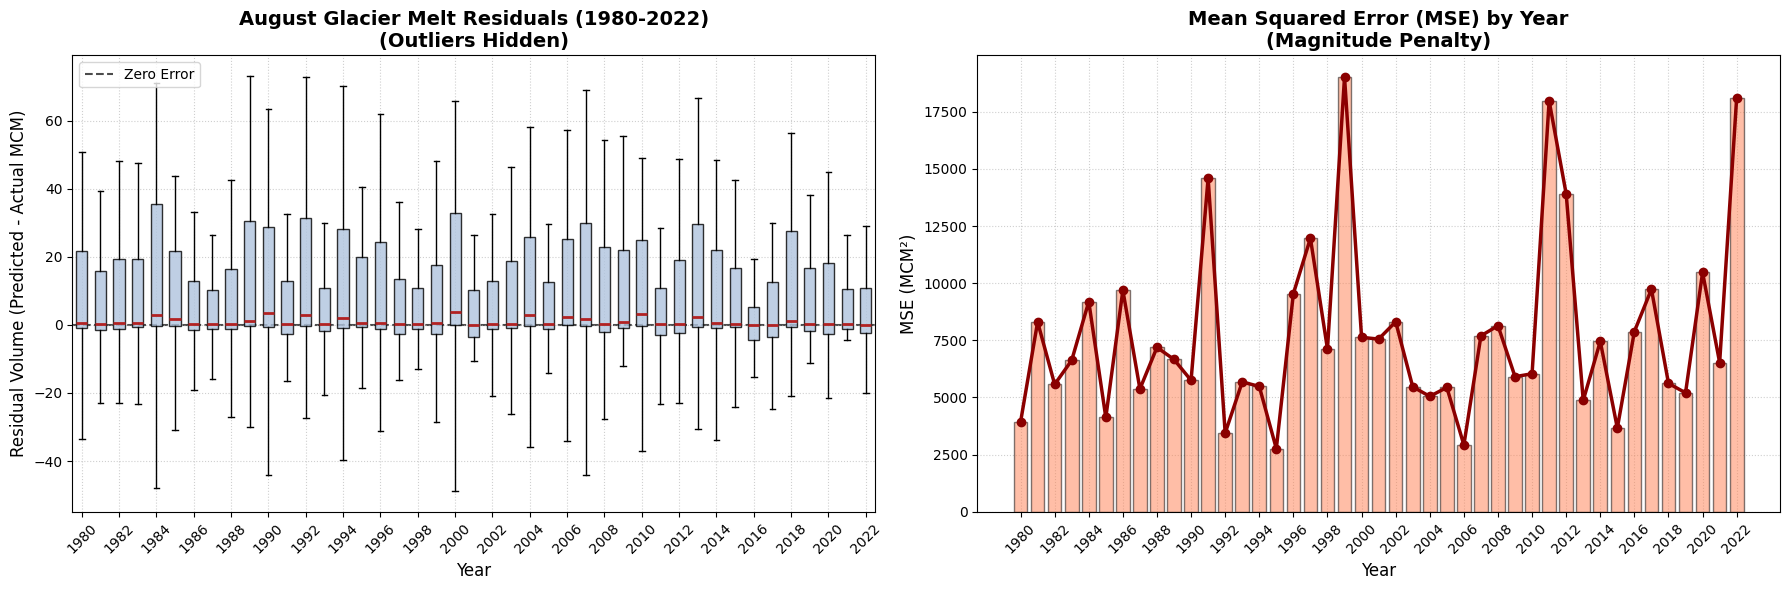

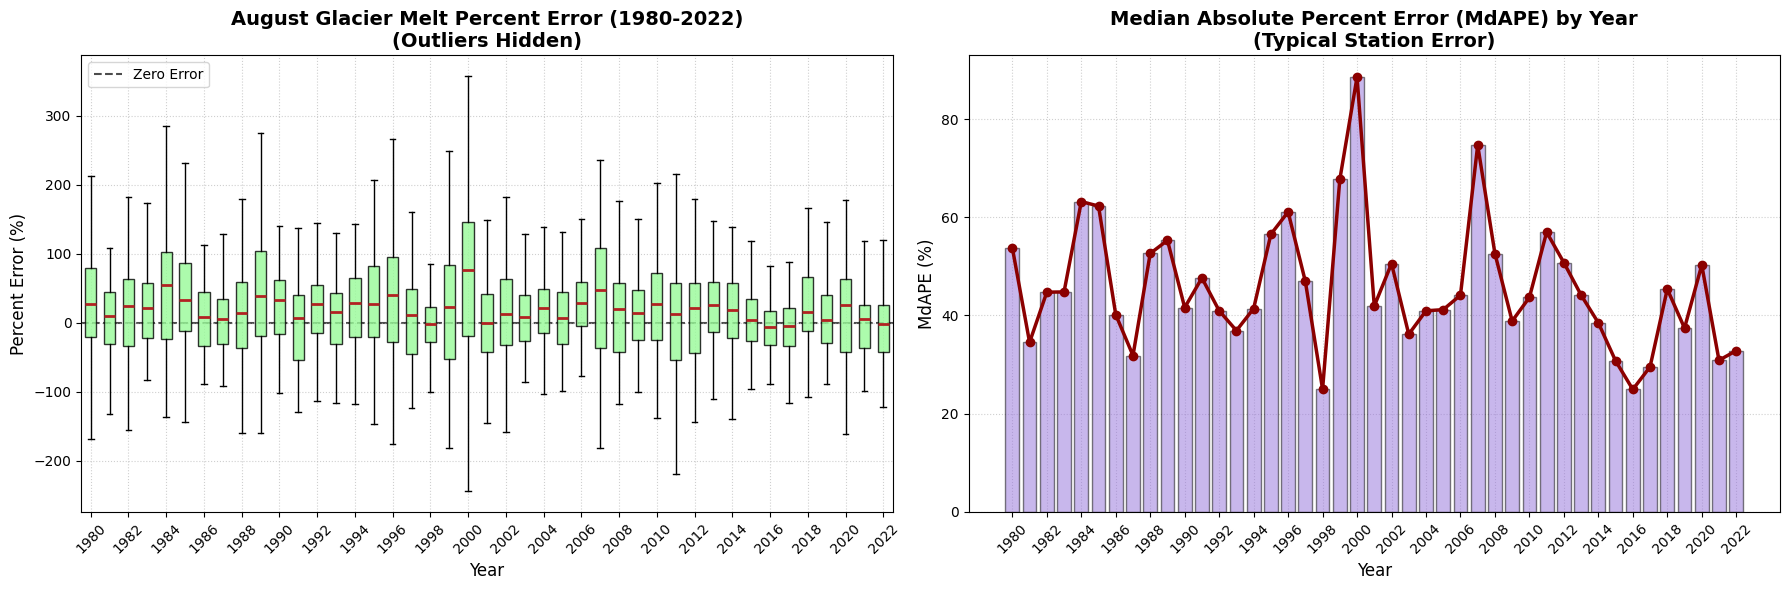

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from src.config import PROCESSED_DATA_DIR, OUTPUT_DATA_DIR

warnings.filterwarnings('ignore')

# =========================================================
# 1. Setup & Load Data (Full Timeline)
# =========================================================
print("Loading data and calculating ensemble means for 1980-2022...")

df_attr = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0)
df_mb = -pd.read_csv(PROCESSED_DATA_DIR / "glacier_volume_change.csv", index_col=0, parse_dates=True) # Native MCM

# Identify glaciated stations
glaciated_stations = df_attr[df_attr['glacier_pct'] > 0].index

# Load ONE template just to get the columns (stations) available in the predictions
template = pd.read_csv(OUTPUT_DATA_DIR / "phase_split" / "phase-split_preds_member_0.csv", index_col=0, nrows=1)
common_stations = glaciated_stations.intersection(template.columns).intersection(df_mb.columns)

df_mb_full = df_mb[common_stations].copy()
basin_areas = df_attr.loc[common_stations, 'basin_area_km2']

# =========================================================
# 2. Calculate Ensemble Means & Melt Volumes (1980-2022)
# =========================================================
ensemble_dir = OUTPUT_DATA_DIR / "phase_split"
list_pred, list_noglac = [], []

for i in range(10):
    # Load full timeline
    pred = pd.read_csv(ensemble_dir / f"phase-split_preds_member_{i}.csv", index_col=0, parse_dates=True)[common_stations]
    noglac = pd.read_csv(ensemble_dir / f"phase-split_preds_noglacier_member_{i}.csv", index_col=0, parse_dates=True)[common_stations]
    list_pred.append(pred)
    list_noglac.append(noglac)

# Ensemble Mean (mm/day)
df_pred_mean = sum(list_pred) / 10
df_noglac_mean = sum(list_noglac) / 10

# Calculate daily difference (mm/day)
df_diff_mm = df_pred_mean - df_noglac_mean

# Isolate August and calculate monthly sum (mm/month)
df_diff_aug_mm = df_diff_mm[df_diff_mm.index.month == 8].groupby(df_diff_mm[df_diff_mm.index.month == 8].index.year).sum()

# Convert predicted depth to volume (MCM)
df_pred_mcm = df_diff_aug_mm * basin_areas * 0.001

# Extract Actual MCM
df_act_mcm = df_mb_full[df_mb_full.index.month == 8].groupby(df_mb_full[df_mb_full.index.month == 8].index.year).sum()

# Align years strictly to 1980-2022
common_years = df_act_mcm.index.intersection(df_pred_mcm.index)
common_years = common_years[(common_years >= 1980) & (common_years <= 2022)]

df_pred_mcm = df_pred_mcm.loc[common_years]
df_act_mcm = df_act_mcm.loc[common_years]

# =========================================================
# 3. Calculate Errors (Residuals, MSE, Pct Error, MdAPE)
# =========================================================
print("Calculating Yearly Error Metrics...")

years = common_years.tolist()

# --- Absolute Residuals (MCM) ---
df_residual = df_pred_mcm - df_act_mcm
mse_per_year = (df_residual ** 2).mean(axis=1)

# --- Percent Errors (%) ---
# Mask out actual melt values that are too close to zero to prevent infinity/massive spikes
safe_act_mcm = df_act_mcm.copy()
safe_act_mcm[safe_act_mcm < 0.01] = np.nan 

df_pct_error = (df_residual / safe_act_mcm) * 100

# Use Median Absolute Percent Error (MdAPE) because the Mean is too sensitive to outliers
mdape_per_year = df_pct_error.abs().median(axis=1)

# Prepare lists of non-NaN arrays for the boxplots
res_data = [df_residual.loc[y].dropna().values for y in years]
pct_data = [df_pct_error.loc[y].dropna().values for y in years]

# =========================================================
# 4. Plotting Function
# =========================================================
def plot_yearly_metrics(box_data, line_data, years, 
                        box_ylabel, line_ylabel, box_title, line_title, 
                        box_color, line_color, is_percent=False):
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # --- Boxplot ---
    # showfliers=False removes the outliers from the visualization
    bp = axes[0].boxplot(box_data, positions=years, patch_artist=True, widths=0.6, showfliers=False,
                         boxprops=dict(facecolor=box_color, color='black', alpha=0.8),
                         capprops=dict(color='black'),
                         whiskerprops=dict(color='black'),
                         medianprops=dict(color='firebrick', linewidth=2))

    axes[0].axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7, zorder=0, label='Zero Error')
    axes[0].set_title(box_title, fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Year', fontsize=12)
    axes[0].set_ylabel(box_ylabel, fontsize=12)
    axes[0].set_xticks(years[::2]) # Show every other year to prevent crowding
    axes[0].set_xticklabels(years[::2], rotation=45)
    axes[0].grid(True, linestyle=':', alpha=0.6)
    axes[0].legend(loc='upper left')

    # --- Bar/Line Plot ---
    axes[1].bar(years, line_data.values, color=line_color, alpha=0.5, edgecolor='black', zorder=2)
    axes[1].plot(years, line_data.values, color='darkred', marker='o', linewidth=2.5, markersize=6, zorder=3)
    
    axes[1].set_title(line_title, fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Year', fontsize=12)
    axes[1].set_ylabel(line_ylabel, fontsize=12)
    axes[1].set_xticks(years[::2])
    axes[1].set_xticklabels(years[::2], rotation=45)
    axes[1].grid(True, linestyle=':', alpha=0.6, zorder=0)
    
    plt.tight_layout()
    plt.show()

# =========================================================
# 5. Generate Figures
# =========================================================

# FIGURE 1: Residuals & MSE
plot_yearly_metrics(
    box_data=res_data, line_data=mse_per_year, years=years,
    box_ylabel='Residual Volume (Predicted - Actual MCM)', 
    line_ylabel='MSE (MCM²)',
    box_title='August Glacier Melt Residuals (1980-2022)\n(Outliers Hidden)', 
    line_title='Mean Squared Error (MSE) by Year\n(Magnitude Penalty)',
    box_color='lightsteelblue', line_color='coral'
)

# FIGURE 2: Percent Error & Absolute Percent Error (MdAPE)
plot_yearly_metrics(
    box_data=pct_data, line_data=mdape_per_year, years=years,
    box_ylabel='Percent Error (%)', 
    line_ylabel='MdAPE (%)',
    box_title='August Glacier Melt Percent Error (1980-2022)\n(Outliers Hidden)', 
    line_title='Median Absolute Percent Error (MdAPE) by Year\n(Typical Station Error)',
    box_color='palegreen', line_color='mediumpurple', is_percent=True
)

Interestingly, we have the most error centered around 2000. Would've expected 2000 to be lower. I expect this is probably pretty dependent on seasonality and also how much the glacier area actually changed. Will want to work with a dataset of the actual ice change to see